# **ANN 10 – Write a Python program to implement a Hopfield Network for pattern storage and retrieval.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class HopfieldNetwork:
    """
    A Hopfield Network for storing and retrieving bipolar patterns.
    """
    def __init__(self, num_neurons):
        """
        Initializes the network.
        
        Args:
            num_neurons (int): The size of the patterns to be stored (number of neurons).
        """
        self.num_neurons = num_neurons
        self.W = np.zeros((num_neurons, num_neurons))

    def train(self, patterns):
        """
        Trains the network on a set of bipolar patterns using the Hebbian rule.
        
        Args:
            patterns (np.array): A 2D array of patterns to store.
        """
        num_patterns = patterns.shape[0]
        # Hebbian learning: W = sum(pattern * pattern^T)
        self.W = np.dot(patterns.T, patterns)
        
        # Remove self-connections by setting the diagonal to zero
        np.fill_diagonal(self.W, 0)
        
        # Optional: Normalize by the number of patterns
        self.W = self.W / num_patterns
        print("Training complete. Weight matrix is set.")

    def _activation(self, x):
        """Bipolar activation function."""
        return np.where(x >= 0, 1, -1)

    def retrieve(self, noisy_pattern, max_iterations=20):
        """
        Retrieves a stored pattern from a noisy input using asynchronous updates.

        Args:
            noisy_pattern (np.array): The corrupted pattern to start with.
            max_iterations (int): Max number of full passes to prevent infinite loops.

        Returns:
            np.array: The retrieved stable pattern.
        """
        current_pattern = noisy_pattern.copy()
        print(f"Starting retrieval with noisy pattern: {current_pattern}")

        for i in range(max_iterations):
            is_stable = True
            # Create a random order for updating neurons
            update_order = np.random.permutation(self.num_neurons)
            
            for n in update_order:
                # Calculate the net input for the current neuron
                net_input = np.dot(self.W[n, :], current_pattern)
                
                # Update the neuron's state
                new_state = self._activation(net_input)
                
                if new_state != current_pattern[n]:
                    current_pattern[n] = new_state
                    is_stable = False
            
            print(f"Iteration {i+1}: {current_pattern}")

            if is_stable:
                print(f"\nNetwork settled into a stable state after {i+1} iterations.")
                return current_pattern
        
        print("\nMax iterations reached. Network did not find a stable state.")
        return current_pattern

def plot_pattern(pattern, title=""):
    """Visualizes a 4-element pattern as a 2x2 grid."""
    plt.imshow(pattern.reshape(2, 2), cmap='gray_r', interpolation='nearest')
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

Training complete. Weight matrix is set.
Starting retrieval with noisy pattern: [ 1 -1  1  1]
Iteration 1: [ 1 -1  1 -1]
Iteration 2: [ 1 -1  1 -1]

Network settled into a stable state after 2 iterations.

--- Visualization of Retrieval ---


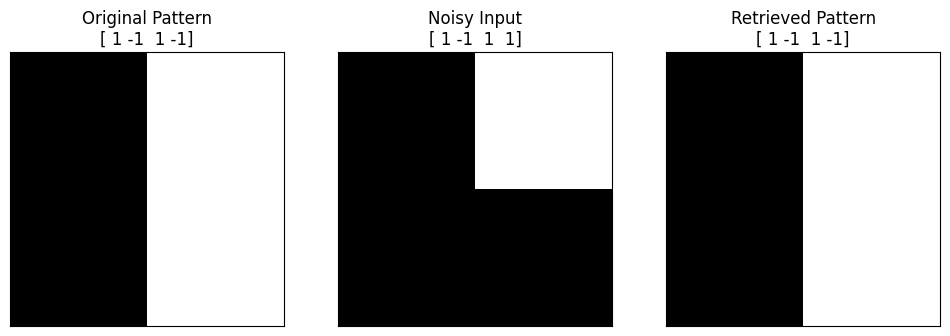

In [3]:
# --- Example Usage ---
if __name__ == "__main__":
    # 1. Define 4 bipolar patterns to be stored.
    pattern1 = np.array([1, 1, -1, -1])
    pattern2 = np.array([-1, -1, 1, 1])
    pattern3 = np.array([1, -1, 1, -1])
    pattern4 = np.array([-1, 1, -1, 1])
    
    patterns = np.array([pattern1, pattern2, pattern3, pattern4])
    num_neurons = patterns.shape[1]

    # 2. Create and train the Hopfield network
    hopfield_net = HopfieldNetwork(num_neurons)
    hopfield_net.train(patterns)

    # 3. Create a noisy version of one of the patterns
    # Corrupt pattern3 by flipping the last bit
    noisy_pattern = np.array([1, -1, 1, 1])

    # 4. Retrieve the original pattern from the noisy input
    retrieved_pattern = hopfield_net.retrieve(noisy_pattern)
    
    # 5. Visualize the results
    print("\n--- Visualization of Retrieval ---")
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Original
    axes[0].imshow(pattern3.reshape(2, 2), cmap='gray_r', interpolation='nearest')
    axes[0].set_title(f"Original Pattern\n{pattern3}")
    
    # Noisy
    axes[1].imshow(noisy_pattern.reshape(2, 2), cmap='gray_r', interpolation='nearest')
    axes[1].set_title(f"Noisy Input\n{noisy_pattern}")
    
    # Retrieved
    axes[2].imshow(retrieved_pattern.reshape(2, 2), cmap='gray_r', interpolation='nearest')
    axes[2].set_title(f"Retrieved Pattern\n{retrieved_pattern}")
    
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.show()